In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.stats.mstats import winsorize
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier 
import sklearn.neighbors
from imblearn.over_sampling import SMOTE
import joblib

import warnings
warnings.filterwarnings('ignore')

# Reading Data

In [2]:
df = pd.read_csv("D:\Water_Data.csv")

In [3]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.830976,190.799044,7695.063935,4.845205,292.515825,507.445488,15.526658,85.009506,4.588785,No
1,4.430281,139.685759,28862.257170,8.961372,298.379458,434.781267,17.299294,63.042501,4.384565,No
2,7.240740,201.186804,23783.099560,7.751285,340.983683,579.220394,13.486379,62.650236,3.556297,No
3,NaN,260.205360,19517.724800,8.764169,368.821037,251.020899,12.804588,48.651890,3.665522,No
4,6.867301,174.184976,24112.153470,5.529942,297.655575,484.122939,11.482687,65.304414,3.823595,No


In [4]:
df.shape

(3318, 10)

In [5]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,2821.000000,3318.000000,3317.000000,3318.000000,2524.000000,3318.000000,3318.000000,3152.000000,3318.000000
mean,7.085656,196.404985,22019.031654,7.125305,333.883350,426.070980,14.292210,66.395487,3.965510
std,1.599928,32.841361,8750.832348,1.588980,41.440818,80.931025,3.313630,16.175299,0.778974
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000
25%,6.090016,176.947115,15677.970690,6.127804,307.706750,365.481133,12.066018,55.831102,3.439577
50%,7.035037,196.928061,20944.620810,7.133077,333.101965,421.440803,14.220645,66.610937,3.954025
75%,8.064170,216.675125,27317.099440,8.118023,360.103704,481.673377,16.572893,77.324282,4.497985
max,14.000000,323.124000,61227.196010,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3318 entries, 0 to 3317
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2821 non-null   float64
 1   Hardness         3318 non-null   float64
 2   Solids           3317 non-null   float64
 3   Chloramines      3318 non-null   float64
 4   Sulfate          2524 non-null   float64
 5   Conductivity     3318 non-null   float64
 6   Organic_carbon   3318 non-null   float64
 7   Trihalomethanes  3152 non-null   float64
 8   Turbidity        3318 non-null   float64
 9   Potability       3318 non-null   object 
dtypes: float64(9), object(1)
memory usage: 259.3+ KB


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.shape

(3277, 10)

In [9]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,2786.000000,3277.000000,3276.000000,3277.000000,2495.000000,3277.000000,3277.000000,3114.000000,3277.000000
mean,7.080858,196.366870,22014.092526,7.122299,333.775777,426.180725,14.283935,66.392550,3.966878
std,1.594037,32.875086,8768.570828,1.582844,41.416840,80.823784,3.308188,16.174778,0.780281
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000
25%,6.093697,176.853696,15666.690300,6.127804,307.699498,365.720291,12.065317,55.844536,3.439740
50%,7.037422,196.952875,20927.833605,7.130437,333.073546,421.879854,14.217373,66.617005,3.955091
75%,8.061702,216.665319,27332.762125,8.114731,359.950170,481.771934,16.557177,77.337473,4.500208
max,14.000000,323.124000,61227.196010,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000


# Overview on the data

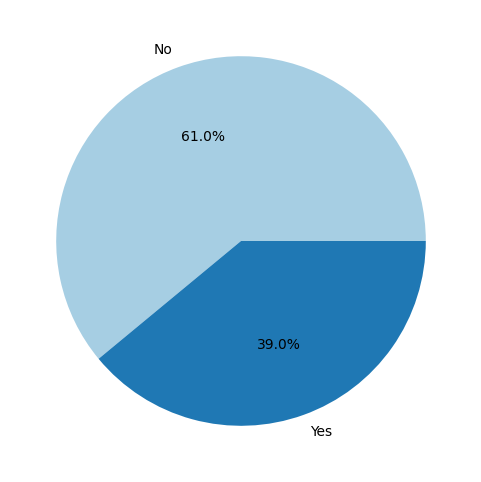

In [10]:
Potability_count = df['Potability'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(Potability_count, labels=Potability_count.index, autopct='%.1f%%', colors=plt.cm.Paired(range(len(Potability_count))))
plt.show()

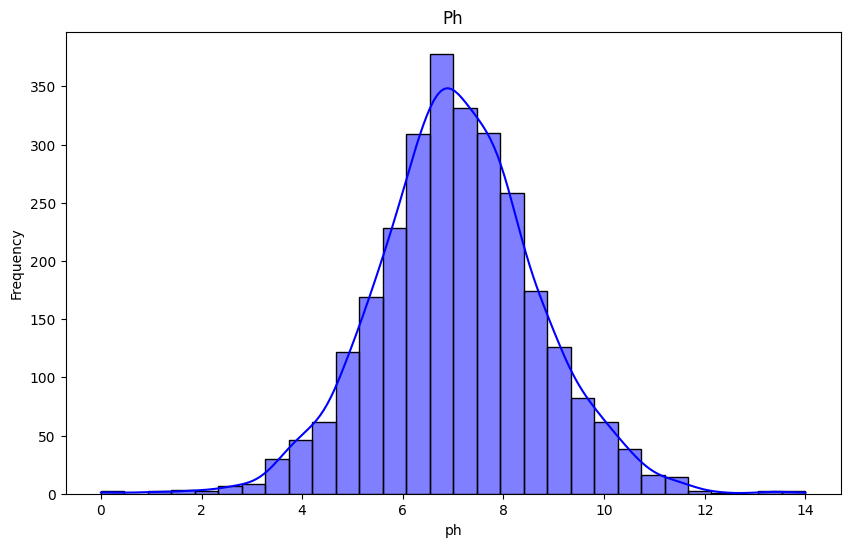

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['ph'], bins=30, kde=True, color='blue')
plt.title('Ph')
plt.xlabel('ph')
plt.ylabel('Frequency')
plt.show()


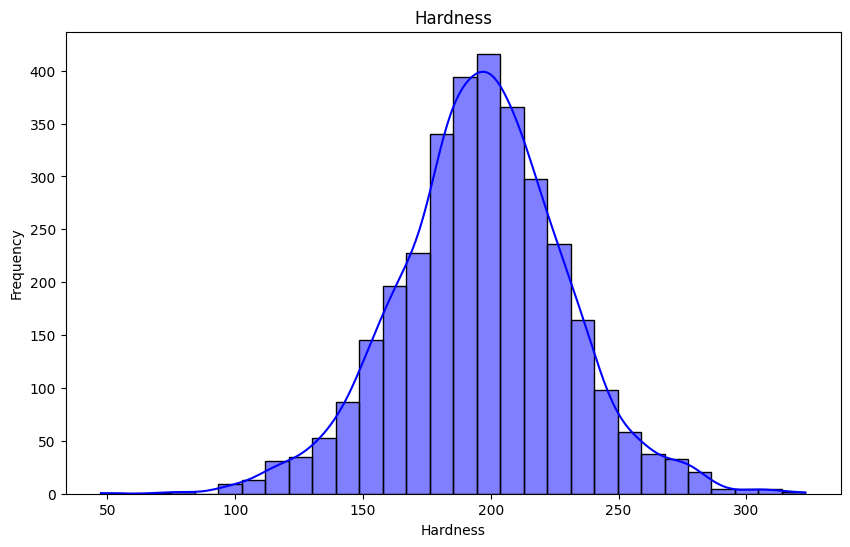

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Hardness'], bins=30, kde=True, color='blue')
plt.title('Hardness')
plt.xlabel('Hardness')
plt.ylabel('Frequency')
plt.show()


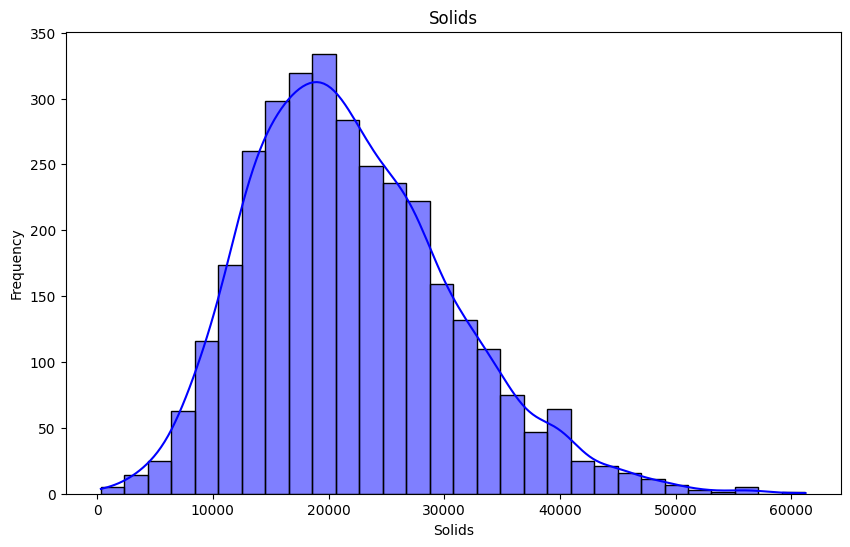

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Solids'], bins=30, kde=True, color='blue')
plt.title('Solids')
plt.xlabel('Solids')
plt.ylabel('Frequency')
plt.show()

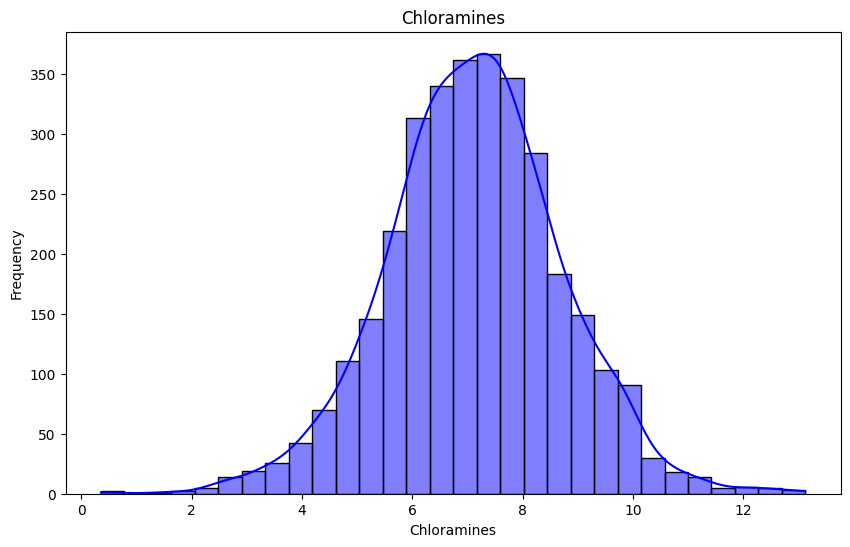

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Chloramines'], bins=30, kde=True, color='blue')
plt.title('Chloramines')
plt.xlabel('Chloramines')
plt.ylabel('Frequency')
plt.show()

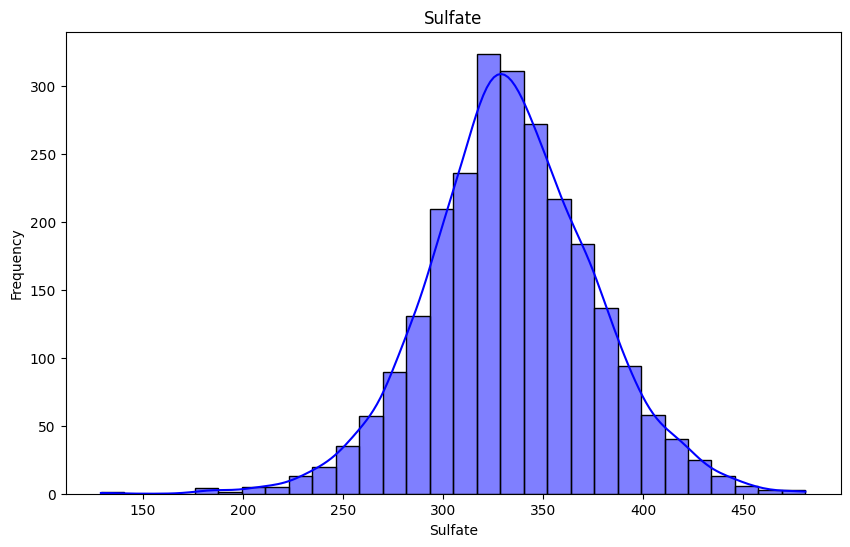

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sulfate'], bins=30, kde=True, color='blue')
plt.title('Sulfate')
plt.xlabel('Sulfate')
plt.ylabel('Frequency')
plt.show()

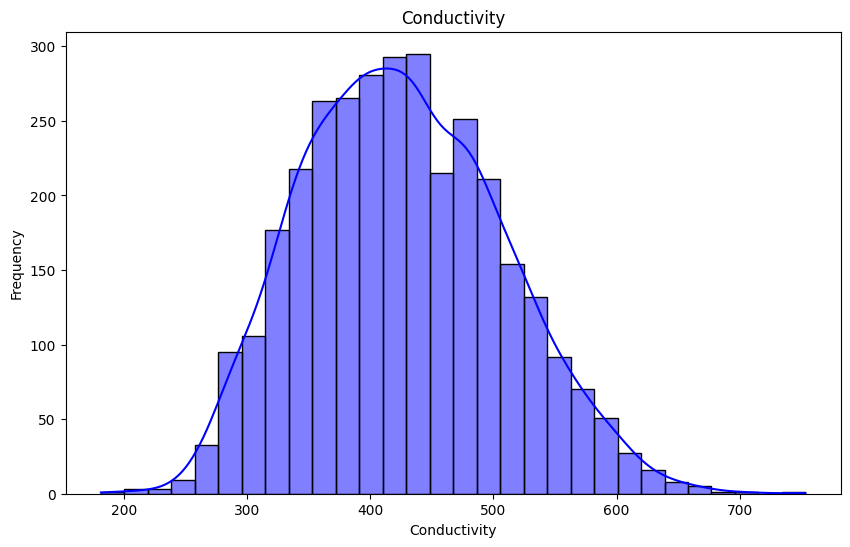

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Conductivity'], bins=30, kde=True, color='blue')
plt.title('Conductivity')
plt.xlabel('Conductivity')
plt.ylabel('Frequency')
plt.show()

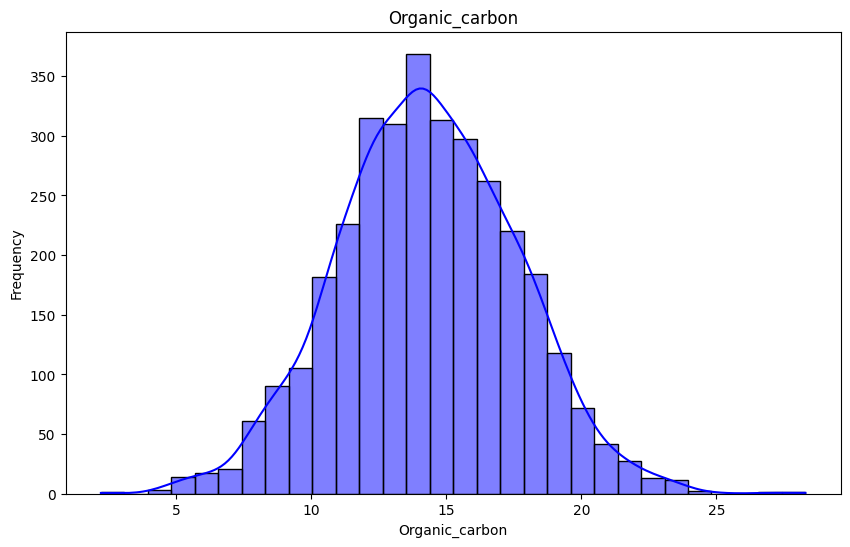

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Organic_carbon'], bins=30, kde=True, color='blue')
plt.title('Organic_carbon')
plt.xlabel('Organic_carbon')
plt.ylabel('Frequency')
plt.show()

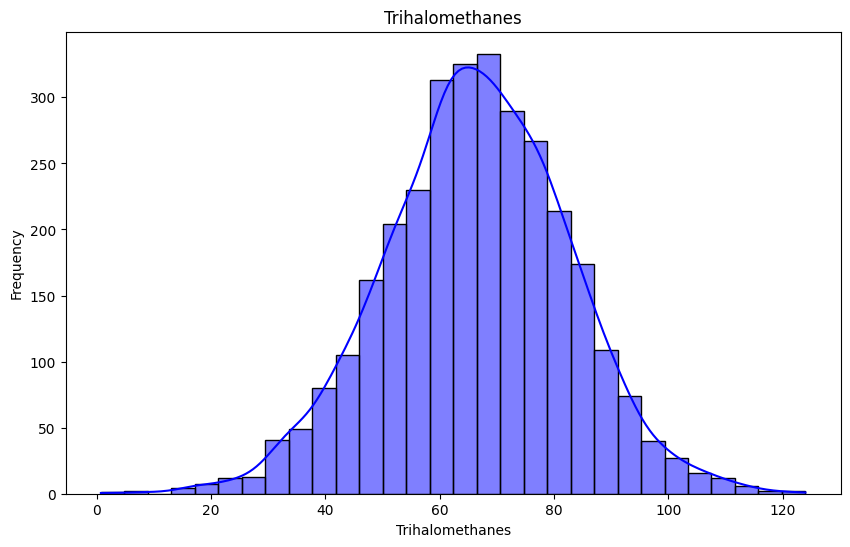

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Trihalomethanes'], bins=30, kde=True, color='blue')
plt.title('Trihalomethanes')
plt.xlabel('Trihalomethanes')
plt.ylabel('Frequency')
plt.show()

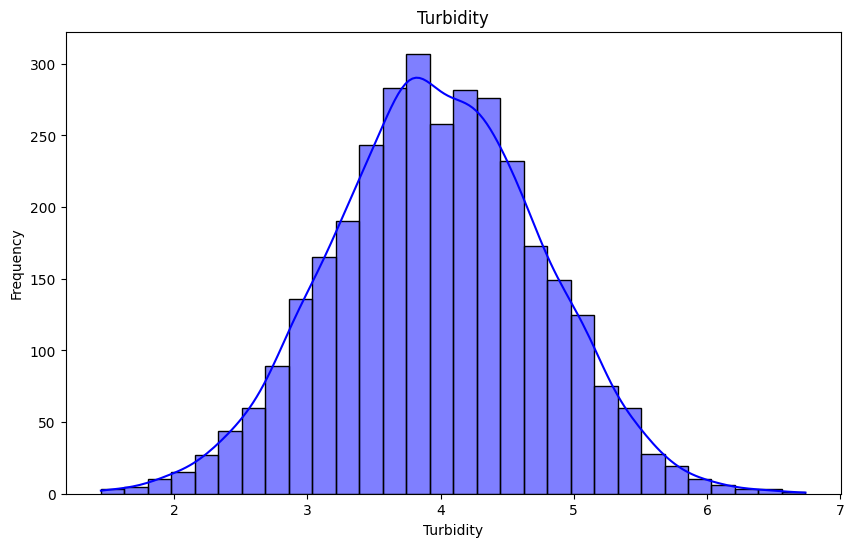

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Turbidity'], bins=30, kde=True, color='blue')
plt.title('Turbidity')
plt.xlabel('Turbidity')
plt.ylabel('Frequency')
plt.show()

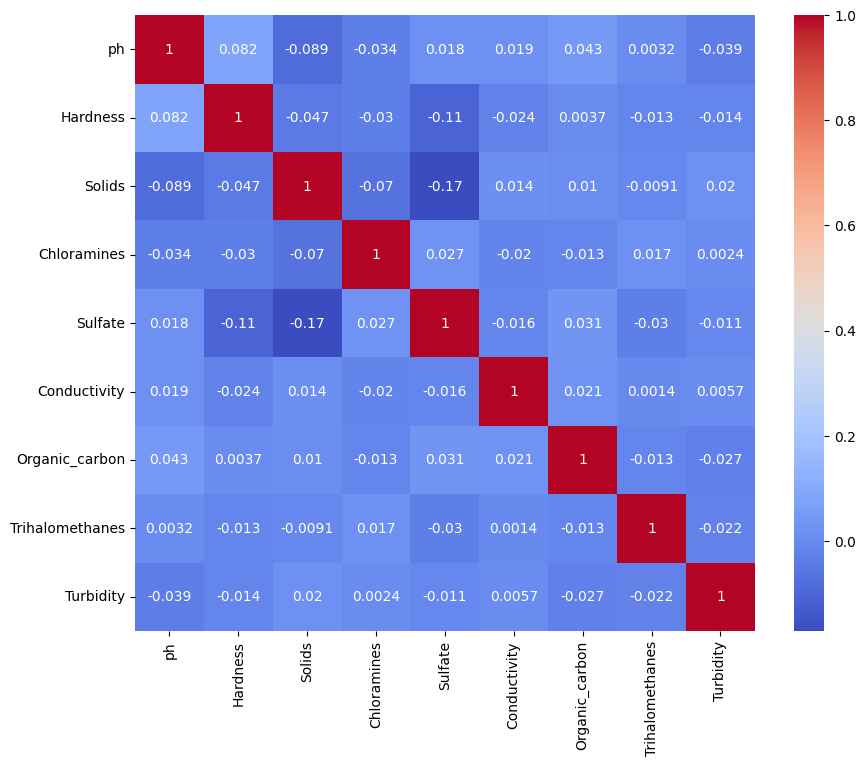

In [20]:
df_corr1=df.drop(columns=['Potability'])
correlation=df_corr1.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()

# Pre-Processing

Nulls

In [21]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               1
Chloramines          0
Sulfate            782
Conductivity         0
Organic_carbon       0
Trihalomethanes    163
Turbidity            0
Potability           0
dtype: int64

In [22]:
percentage = df.isnull().mean() * 100
print(percentage)

ph                 14.983216
Hardness            0.000000
Solids              0.030516
Chloramines         0.000000
Sulfate            23.863290
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.974062
Turbidity           0.000000
Potability          0.000000
dtype: float64


In [23]:
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

In [24]:
df = df.dropna(subset=['Solids'])

In [25]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Encoding

In [26]:
l=LabelEncoder()
df['Potability_encoded']=l.fit_transform(df['Potability'])

In [27]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Potability_encoded
0,7.830976,190.799044,7695.063935,4.845205,292.515825,507.445488,15.526658,85.009506,4.588785,No,0
1,4.430281,139.685759,28862.257170,8.961372,298.379458,434.781267,17.299294,63.042501,4.384565,No,0
2,7.240740,201.186804,23783.099560,7.751285,340.983683,579.220394,13.486379,62.650236,3.556297,No,0
3,7.037422,260.205360,19517.724800,8.764169,368.821037,251.020899,12.804588,48.651890,3.665522,No,0
4,6.867301,174.184976,24112.153470,5.529942,297.655575,484.122939,11.482687,65.304414,3.823595,No,0


Outliers

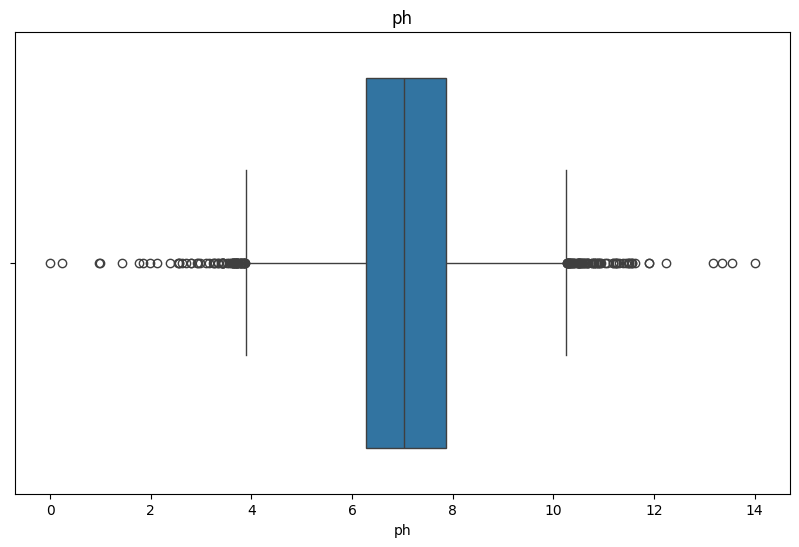

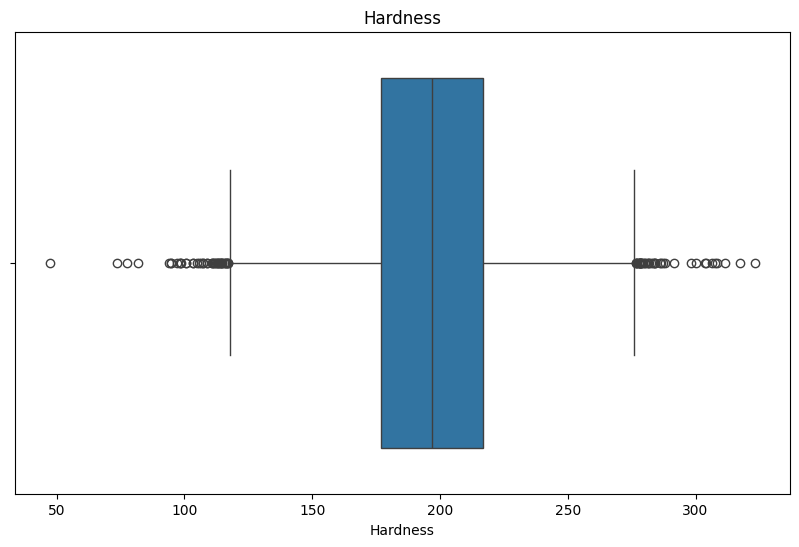

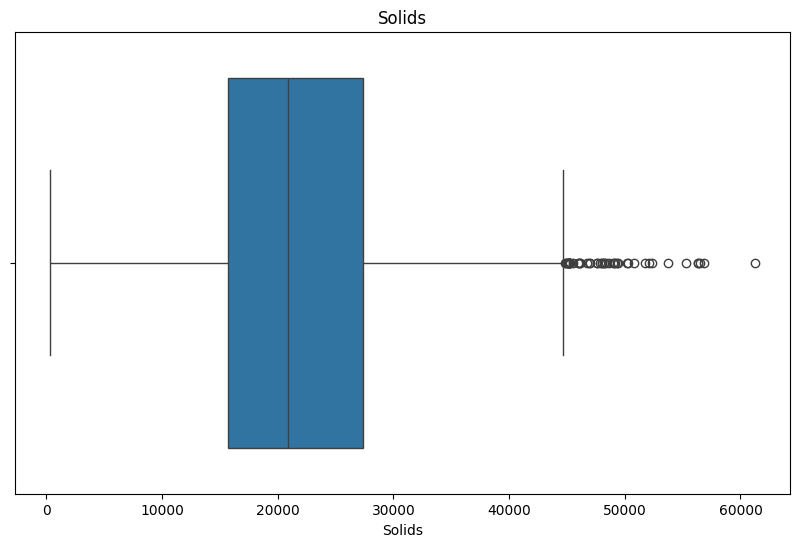

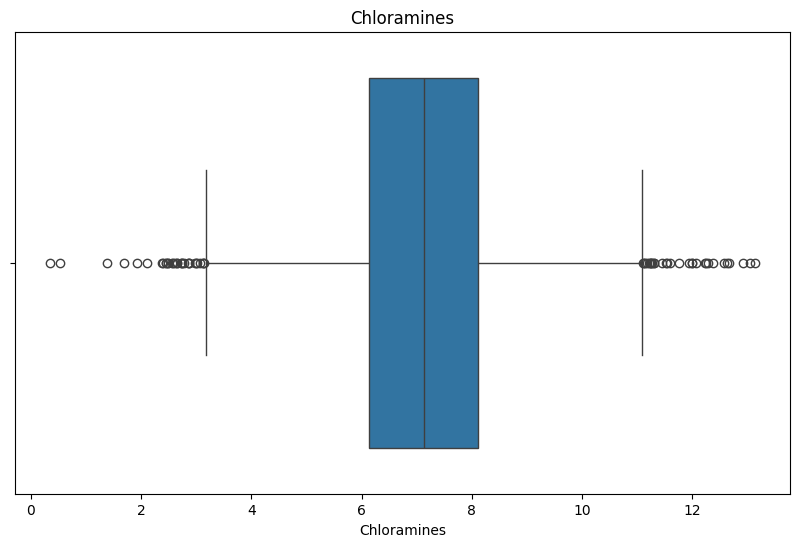

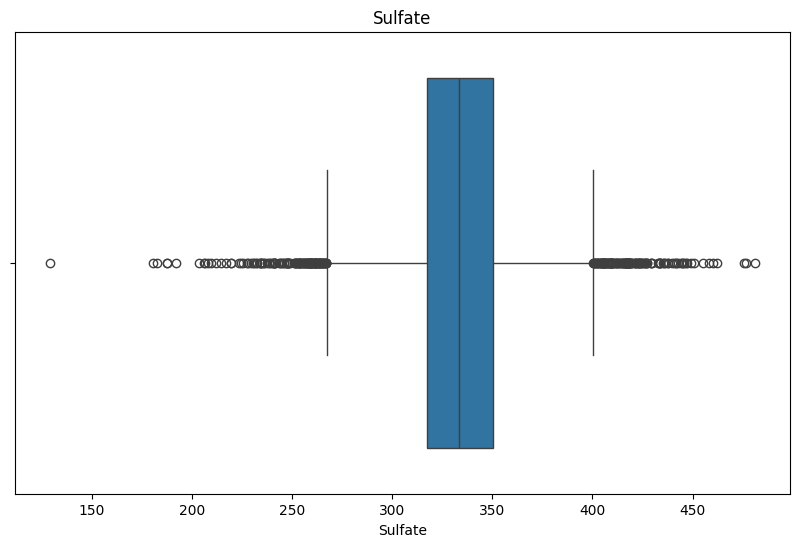

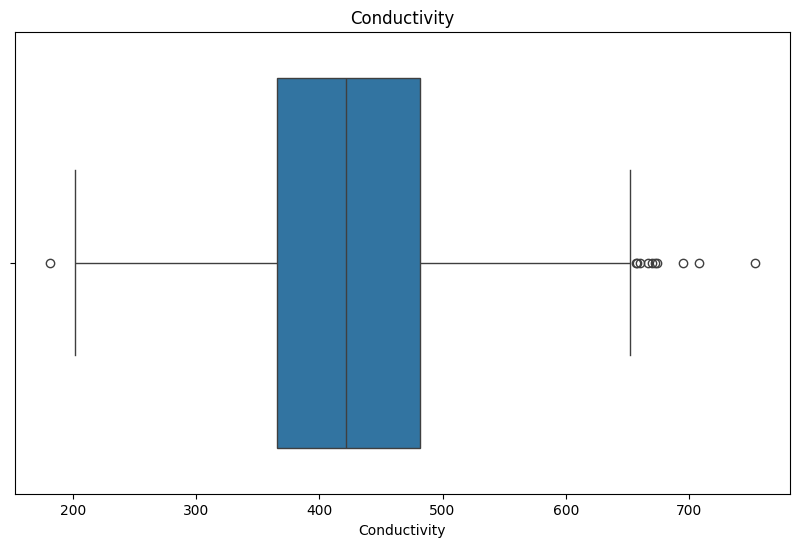

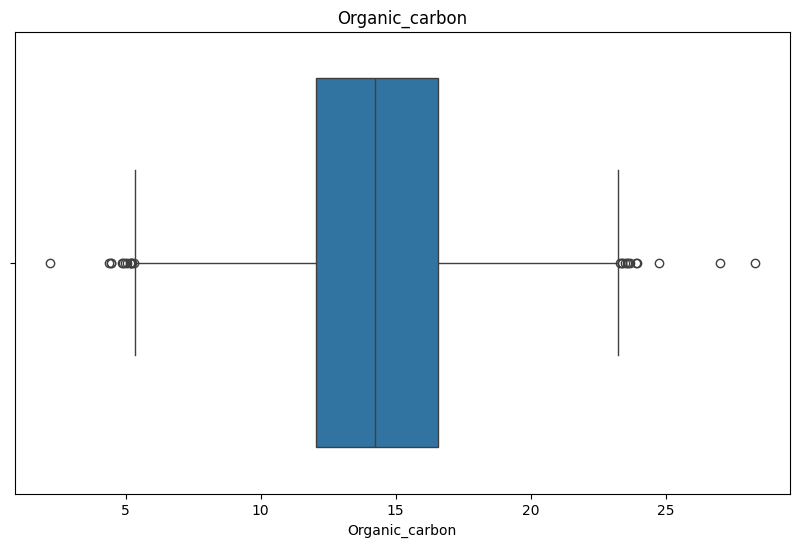

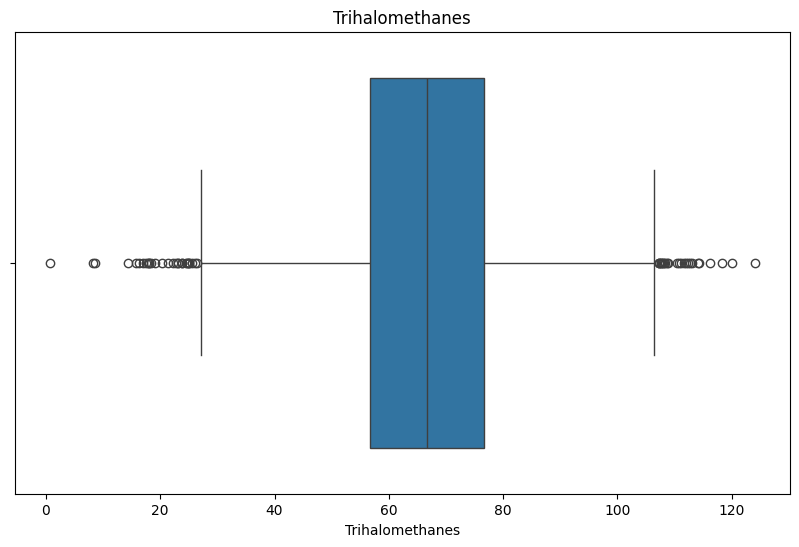

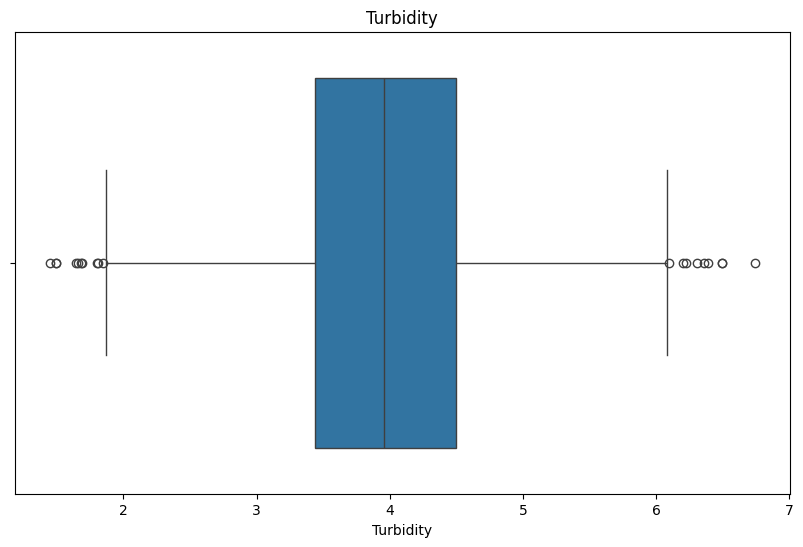

In [28]:
def box_plot(df,column):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[column])
    plt.title(column)
    plt.show()
df_box=df.drop(columns=['Potability','Potability_encoded'])
columns=df_box.columns
for i in columns:
    box_plot(df,i)

In [29]:
def outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return {"column": column, "lower": lower, "upper": upper, "outliers_count": len(outliers)}

In [30]:
for i in columns:
    print(outliers(df, i))

{'column': 'ph', 'lower': np.float64(3.8891069555), 'upper': np.float64(10.258615435500001), 'outliers_count': 142}
{'column': 'Hardness', 'lower': np.float64(117.1251602875), 'upper': np.float64(276.39283378749997), 'outliers_count': 83}
{'column': 'Solids', 'lower': np.float64(-1832.4174374999948), 'upper': np.float64(44831.869862499996), 'outliers_count': 47}
{'column': 'Chloramines', 'lower': np.float64(3.1462213411249986), 'upper': np.float64(11.096086446125003), 'outliers_count': 61}
{'column': 'Sulfate', 'lower': np.float64(267.1579598), 'upper': np.float64(400.32243420000003), 'outliers_count': 264}
{'column': 'Conductivity', 'lower': np.float64(191.6475785875001), 'upper': np.float64(655.8791400874999), 'outliers_count': 11}
{'column': 'Organic_carbon', 'lower': np.float64(5.328026021249996), 'upper': np.float64(23.295426851250006), 'outliers_count': 25}
{'column': 'Trihalomethanes', 'lower': np.float64(26.619225160000003), 'upper': np.float64(106.69503986), 'outliers_count': 

In [31]:
def win_outliers(df,column):
  df[column]=winsorize(df[column],limits=[0.05,0.05])

In [32]:
for i in columns:
  win_outliers(df,i)

In [33]:
for i in columns:
    print(outliers(df, i))

{'column': 'ph', 'lower': np.float64(3.8891069555), 'upper': np.float64(10.258615435500001), 'outliers_count': 0}
{'column': 'Hardness', 'lower': np.float64(117.1251602875), 'upper': np.float64(276.39283378749997), 'outliers_count': 0}
{'column': 'Solids', 'lower': np.float64(-1832.4174374999948), 'upper': np.float64(44831.869862499996), 'outliers_count': 0}
{'column': 'Chloramines', 'lower': np.float64(3.1462213411249986), 'upper': np.float64(11.096086446125003), 'outliers_count': 0}
{'column': 'Sulfate', 'lower': np.float64(267.1579598), 'upper': np.float64(400.32243420000003), 'outliers_count': 0}
{'column': 'Conductivity', 'lower': np.float64(191.6475785875001), 'upper': np.float64(655.8791400874999), 'outliers_count': 0}
{'column': 'Organic_carbon', 'lower': np.float64(5.328026021249996), 'upper': np.float64(23.295426851250006), 'outliers_count': 0}
{'column': 'Trihalomethanes', 'lower': np.float64(26.619225160000003), 'upper': np.float64(106.69503986), 'outliers_count': 0}
{'colu

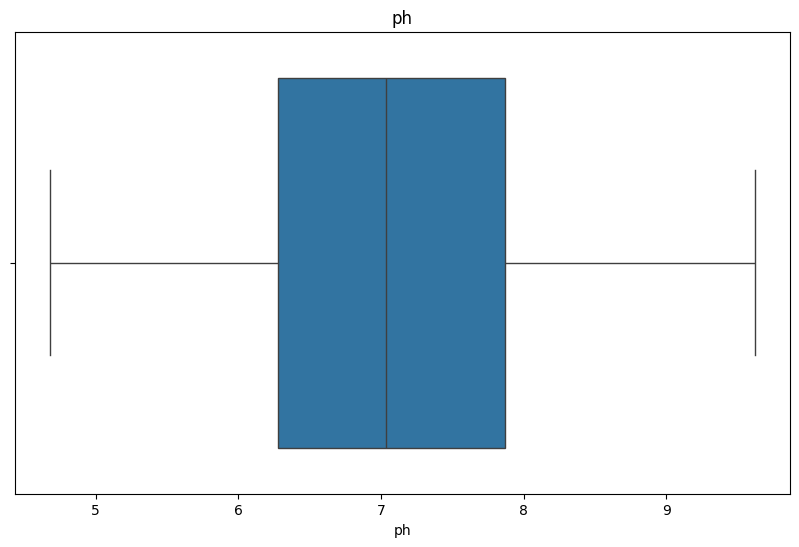

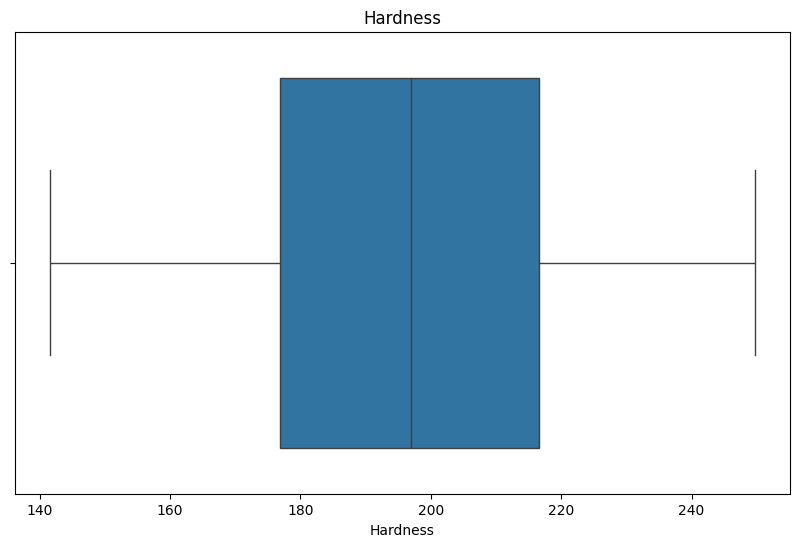

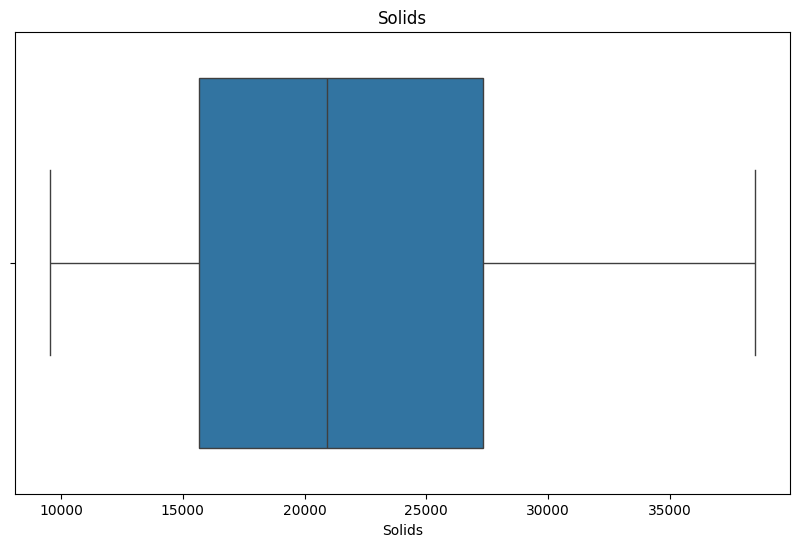

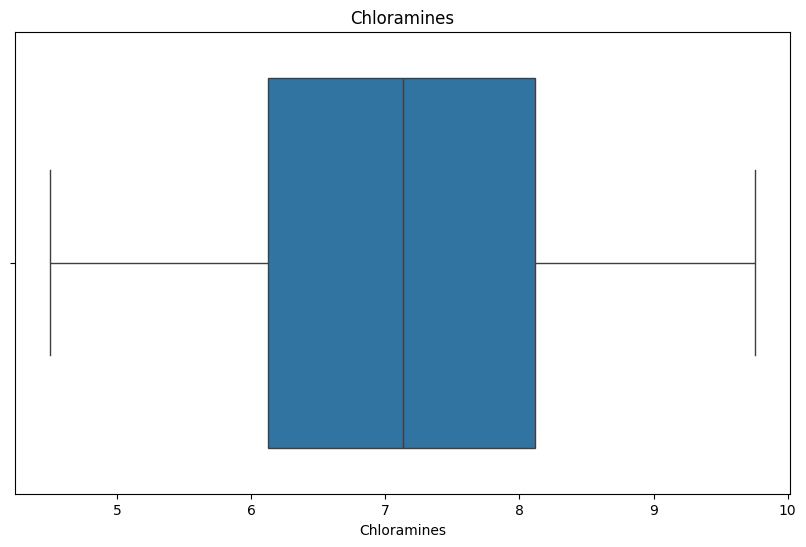

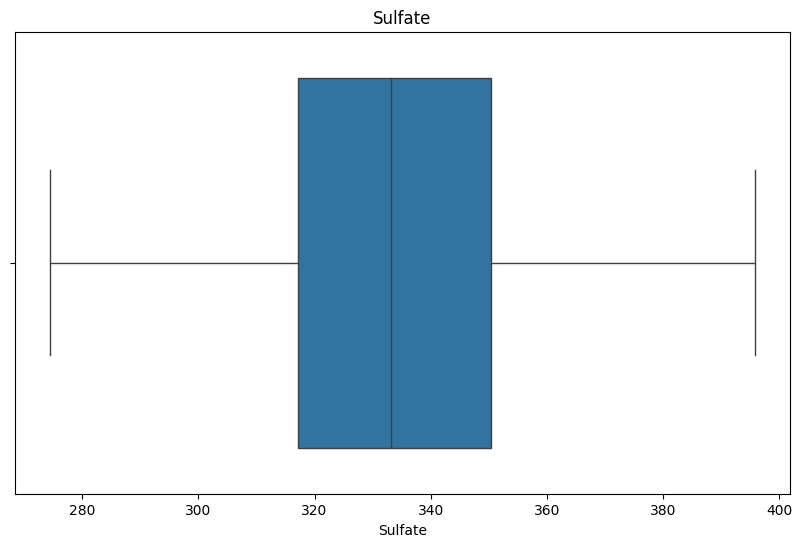

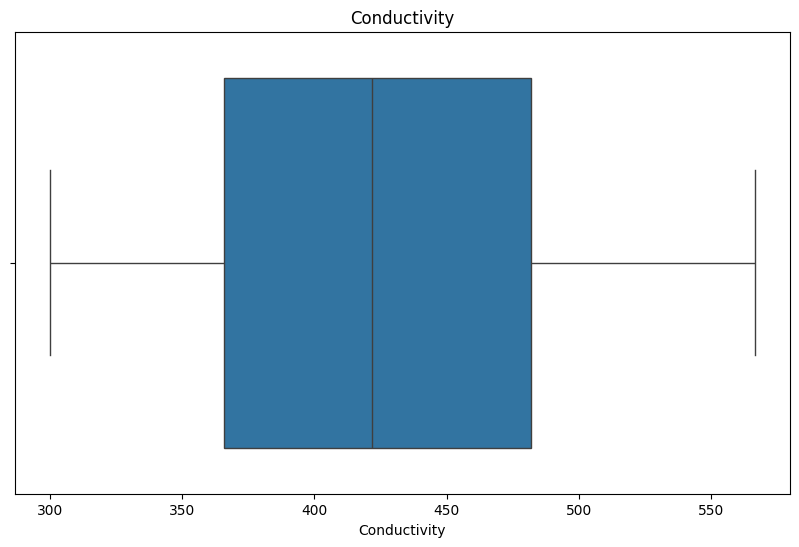

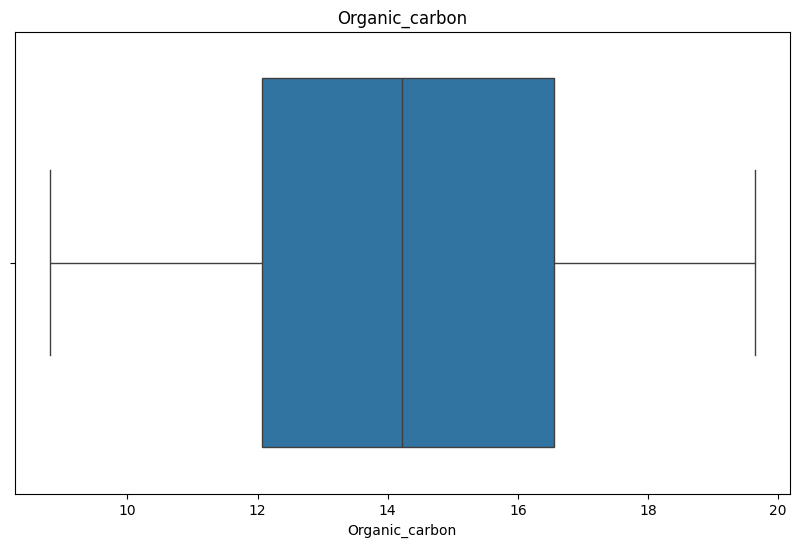

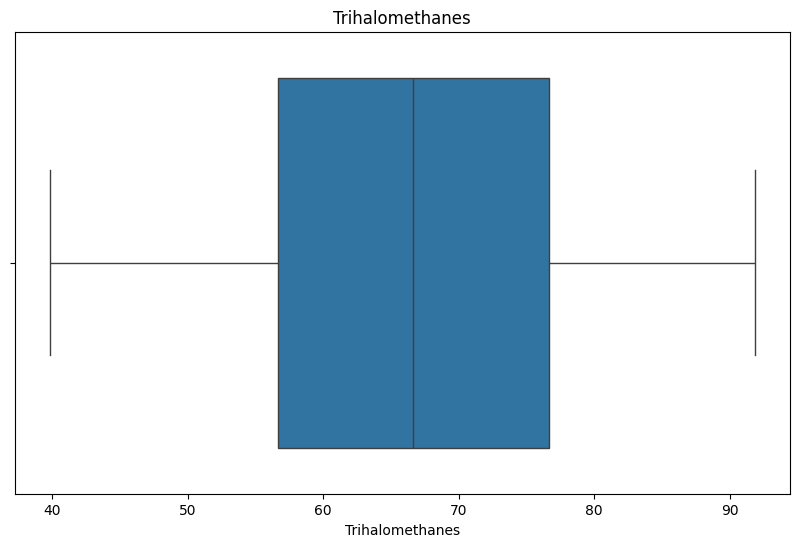

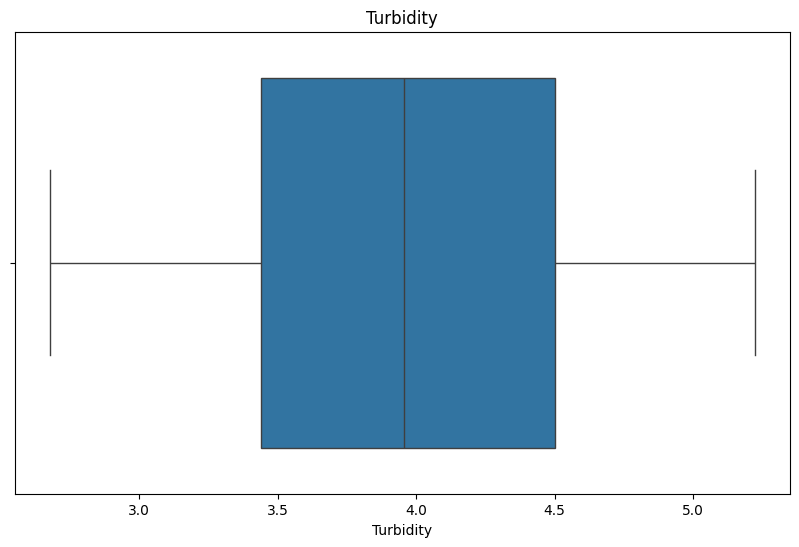

In [34]:
for i in columns:
    box_plot(df,i)

<Axes: >

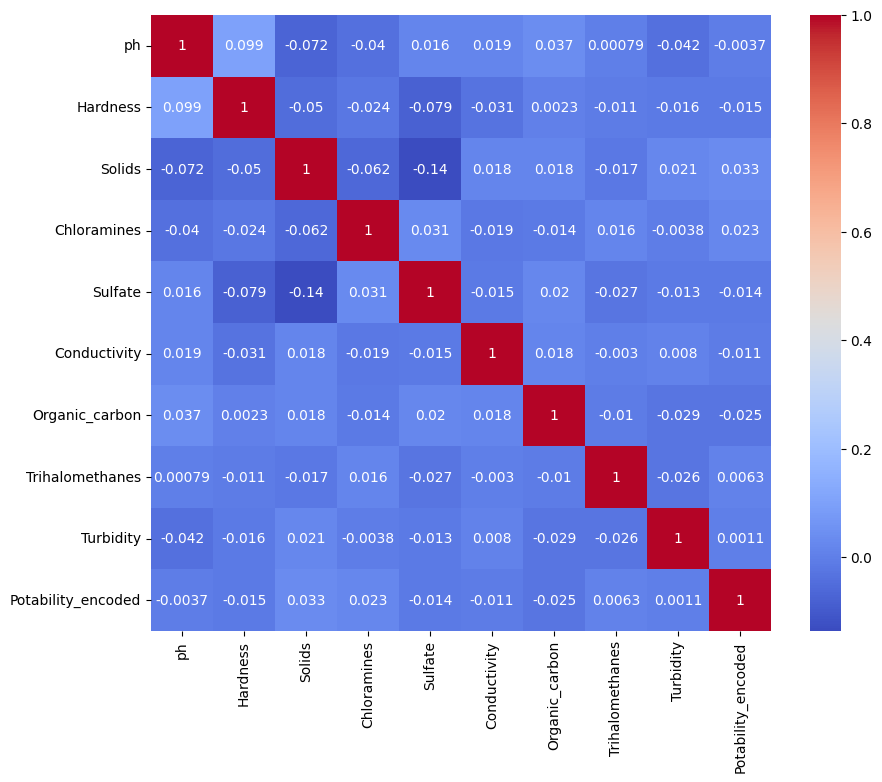

In [35]:
df_corr2=df.drop(columns=['Potability'])
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr2.corr(), annot= True, cmap='coolwarm')

# Data Splitting

In [36]:
#splitting data
x=df.drop(columns=['Potability','Potability_encoded'])
y=df['Potability_encoded']

In [38]:
# x_train, x_, y_train, y_= train_test_split(x, y, test_size=0.40, random_state=1)
# x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.20, random_state=42) 

# Scaling

In [39]:
#scaling

scaler = StandardScaler()
x_scaled=scaler.fit_transform(x)
x_train_scaled = scaler.fit_transform(x_train)
#x_cv_scaled = scaler.transform(x_cv)
x_test_scaled = scaler.transform(x_test)

# oversampling

In [40]:



oversample = SMOTE(sampling_strategy={1: 1998}, random_state=42)


X_resampled3, y_resampled3 = oversample.fit_resample(x, y)



In [42]:
#splitting sampled data
# x_train_s3, x_s3, y_train_s3, y_s3= train_test_split(X_resampled3, y_resampled3, test_size=0.4,random_state=1)
# x_cv_s3, x_test_s3, y_cv_s3, y_test_s3 = train_test_split(x_s3, y_s3, test_size=0.50, random_state=1)

x_train_s3, x_test_s3, y_train_s3, y_test_s3= train_test_split(X_resampled3, y_resampled3, test_size=0.20, random_state=42) 

# oversampling scaled

In [43]:


oversample = SMOTE(sampling_strategy={1: 1998}, random_state=42)


X_resampled2, y_resampled2 = oversample.fit_resample(x_scaled, y)



In [44]:
#splitting sampled data
# x_train_s2, x_s2, y_train_s2, y_s2= train_test_split(X_resampled2, y_resampled2, test_size=0.4,random_state=1)
# x_cv_s2, x_test_s2, y_cv_s2, y_test_s2 = train_test_split(x_s2, y_s2, test_size=0.50, random_state=1)

x_train_s2, x_test_s2, y_train_s2, y_test_s2= train_test_split(X_resampled2, y_resampled2, test_size=0.20, random_state=42) 

# Saving CLean Data

In [45]:
df.to_csv("updated.csv", index=False)

# Models

# SVM

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

In [47]:
#original data

svm = SVC()

grid = GridSearchCV(estimator=svm, param_grid = param_grid, cv=5)
grid.fit(x_train,y_train)



GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']})

In [48]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


In [183]:
svm_orig = SVC(C=10,gamma=0.01,kernel='rbf')
svm_orig.fit(x_train,y_train)

SVC(C=10, gamma=0.01)

In [184]:
train_accuracy = svm_orig.score(x_train, y_train)
# cv_accuracy = svm_orig.score(x_cv, y_cv)
test_accuracy = svm_orig.score(x_test, y_test)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 1.0
Test Accuracy: 0.6082317073170732


In [186]:
y_pred = svm_orig.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[399   1]
 [256   0]]


In [187]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656



In [53]:
#scaled

grid.fit(x_train_scaled,y_train)


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']})

In [54]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [188]:
svm_scaled = SVC(C=100,gamma=0.01,kernel='rbf')
svm_scaled.fit(x_train_scaled,y_train)

SVC(C=100, gamma=0.01)

In [189]:
train_accuracy = svm_scaled.score(x_train_scaled, y_train)
# cv_accuracy = svm_scaled.score(x_cv_scaled, y_cv)
test_accuracy = svm_scaled.score(x_test_scaled, y_test)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.6954198473282442
Test Accuracy: 0.6737804878048781


In [57]:
y_pred = svm_scaled.predict(x_test_scaled)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[371  29]
 [185  71]]


In [58]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.67      0.93      0.78       400
           1       0.71      0.28      0.40       256

    accuracy                           0.67       656
   macro avg       0.69      0.60      0.59       656
weighted avg       0.68      0.67      0.63       656



In [59]:

joblib.dump(svm_scaled, 'models/svm_modelf.pkl')

['models/svm_modelf.pkl']

In [60]:
#sampled

grid.fit(x_train_s3,y_train_s3)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']})

In [61]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}


In [190]:
svm_sampled = SVC(C=10,gamma=0.001,kernel='rbf')
svm_sampled.fit(x_train_s3,y_train_s3)

SVC(C=10, gamma=0.001)

In [191]:
train_accuracy = svm_sampled.score(x_train_s3, y_train_s3)
# cv_accuracy = svm_sampled.score(x_cv_s3, y_cv_s3)
test_accuracy = svm_sampled.score(x_test_s3, y_test_s3)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.9993742177722152
Test Accuracy: 0.6875


In [192]:
y_pred = svm_sampled.predict(x_test_s3)
cm=confusion_matrix(y_test_s3,y_pred)
print(cm)

[[325  77]
 [173 225]]


In [193]:
cr=classification_report(y_test_s3,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.65      0.81      0.72       402
           1       0.75      0.57      0.64       398

    accuracy                           0.69       800
   macro avg       0.70      0.69      0.68       800
weighted avg       0.70      0.69      0.68       800



In [66]:
#combined

grid.fit(x_train_s2,y_train_s2)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']})

In [67]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}


In [194]:
svm_combined = SVC(C=10,gamma=1,kernel='rbf')
svm_combined.fit(x_train_s2,y_train_s2)

SVC(C=10, gamma=1)

In [195]:
train_accuracy = svm_combined.score(x_train_s2, y_train_s2)
# cv_accuracy = svm_combined.score(x_cv_s2, y_cv_s2)
test_accuracy = svm_combined.score(x_test_s2, y_test_s2)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 1.0
Test Accuracy: 0.77


In [197]:
y_pred = svm_combined.predict(x_test_s2)
cm=confusion_matrix(y_test_s2,y_pred)
print(cm)

[[333  69]
 [115 283]]


In [198]:
cr=classification_report(y_test_s2,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.74      0.83      0.78       402
           1       0.80      0.71      0.75       398

    accuracy                           0.77       800
   macro avg       0.77      0.77      0.77       800
weighted avg       0.77      0.77      0.77       800



In [72]:
#best: scaled

# KNN


In [73]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9]
}

knn = sklearn.neighbors.KNeighborsClassifier()

In [74]:
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

In [75]:
#original

grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9]}, scoring='accuracy')

In [76]:
print("Best parameters:", grid.best_params_)

Best parameters: {'n_neighbors': 9}


In [77]:
knn_orig = grid.best_estimator_

In [78]:
train_accuracy = knn_orig.score(x_train, y_train)
# cv_accuracy = knn_orig.score(x_cv, y_cv)
test_accuracy = knn_orig.score(x_test, y_test)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.6629770992366413
Test Accuracy: 0.6112804878048781


In [79]:
y_pred = knn_orig.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[332  68]
 [187  69]]


In [80]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.64      0.83      0.72       400
           1       0.50      0.27      0.35       256

    accuracy                           0.61       656
   macro avg       0.57      0.55      0.54       656
weighted avg       0.59      0.61      0.58       656



In [81]:
#scaled

grid.fit(x_train_scaled,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9]}, scoring='accuracy')

In [82]:
print("Best parameters:", grid.best_params_)

Best parameters: {'n_neighbors': 7}


In [83]:
knn_scaled= grid.best_estimator_

In [84]:
train_accuracy = knn_scaled.score(x_train_scaled, y_train)
# cv_accuracy = knn_scaled.score(x_cv_scaled, y_cv)
test_accuracy = knn_scaled.score(x_test_scaled, y_test)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.7381679389312977
Test Accuracy: 0.6326219512195121


In [85]:
y_pred = knn_scaled.predict(x_test_scaled)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[326  74]
 [167  89]]


In [86]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.66      0.81      0.73       400
           1       0.55      0.35      0.42       256

    accuracy                           0.63       656
   macro avg       0.60      0.58      0.58       656
weighted avg       0.62      0.63      0.61       656



In [87]:
#sampled

grid.fit(x_train_s3,y_train_s3)



GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9]}, scoring='accuracy')

In [88]:
print("Best parameters:", grid.best_params_)

Best parameters: {'n_neighbors': 3}


In [89]:
knn_sampled= grid.best_estimator_

In [90]:
train_accuracy = knn_sampled.score(x_train_s3, y_train_s3)
# cv_accuracy = knn_sampled.score(x_cv_s3, y_cv_s3)
test_accuracy = knn_sampled.score(x_test_s3, y_test_s3)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.8069461827284106
Test Accuracy: 0.6125


In [91]:
y_pred = knn_sampled.predict(x_test_s3)
cm=confusion_matrix(y_test_s3,y_pred)
print(cm)

[[226 176]
 [134 264]]


In [92]:
cr=classification_report(y_test_s3,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.63      0.56      0.59       402
           1       0.60      0.66      0.63       398

    accuracy                           0.61       800
   macro avg       0.61      0.61      0.61       800
weighted avg       0.61      0.61      0.61       800



In [93]:
#combined

grid.fit(x_train_s2,y_train_s2)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9]}, scoring='accuracy')

In [94]:
print("Best parameters:", grid.best_params_)

Best parameters: {'n_neighbors': 3}


In [95]:
knn_combined= grid.best_estimator_

In [96]:
train_accuracy = knn_combined.score(x_train_s2, y_train_s2)
# cv_accuracy = knn_combined.score(x_cv_s2, y_cv_s2)
test_accuracy = knn_combined.score(x_test_s2, y_test_s2)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.8513767209011264
Test Accuracy: 0.67875


In [97]:
y_pred = knn_combined.predict(x_test_s2)
cm=confusion_matrix(y_test_s2,y_pred)
print(cm)

[[242 160]
 [ 97 301]]


In [98]:
cr=classification_report(y_test_s2,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.71      0.60      0.65       402
           1       0.65      0.76      0.70       398

    accuracy                           0.68       800
   macro avg       0.68      0.68      0.68       800
weighted avg       0.68      0.68      0.68       800



In [99]:
joblib.dump(knn_combined, 'models/knn_modelf.pkl')

['models/knn_modelf.pkl']

In [100]:
#best:combined

# Decision Trees

In [101]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 1, 2, 3, 4, 5 ,6 ,7],
    'min_samples_split': [2, 4, 4],
    'min_samples_leaf': [1, 2, 3]
}

d_tree = DecisionTreeClassifier(random_state=42)

In [102]:
grid = GridSearchCV(estimator=d_tree, param_grid=param_grid,cv=5, scoring='accuracy', n_jobs=-1)


In [103]:
#original
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 1, 2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 4]},
             scoring='accuracy')

In [104]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [105]:
d_tree_orig= grid.best_estimator_

In [106]:
train_accuracy = d_tree_orig.score(x_train, y_train)
# cv_accuracy = d_tree_orig.score(x_cv, y_cv)
test_accuracy = d_tree_orig.score(x_test, y_test)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.6606870229007633
Test Accuracy: 0.6234756097560976


In [107]:
y_pred = d_tree_orig.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[353  47]
 [200  56]]


In [108]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.64      0.88      0.74       400
           1       0.54      0.22      0.31       256

    accuracy                           0.62       656
   macro avg       0.59      0.55      0.53       656
weighted avg       0.60      0.62      0.57       656



In [109]:
#scaled
grid.fit(x_train_scaled,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 1, 2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 4]},
             scoring='accuracy')

In [110]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [111]:
d_tree_scaled= grid.best_estimator_

In [112]:
train_accuracy = d_tree_scaled.score(x_train_scaled, y_train)
# cv_accuracy = d_tree_scaled.score(x_cv_scaled, y_cv)
test_accuracy = d_tree_scaled.score(x_test_scaled, y_test)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.6606870229007633
Test Accuracy: 0.6234756097560976


In [113]:
y_pred = d_tree_scaled.predict(x_test_scaled)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[353  47]
 [200  56]]


In [114]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.64      0.88      0.74       400
           1       0.54      0.22      0.31       256

    accuracy                           0.62       656
   macro avg       0.59      0.55      0.53       656
weighted avg       0.60      0.62      0.57       656



In [115]:
joblib.dump(d_tree_scaled, 'models/decisiontree_modelf.pkl')

['models/decisiontree_modelf.pkl']

In [116]:
#sampled

grid.fit(x_train_s3,y_train_s3)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 1, 2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 4]},
             scoring='accuracy')

In [117]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 3, 'min_samples_split': 2}


In [118]:
d_tree_sampled= grid.best_estimator_

In [119]:
train_accuracy = d_tree_sampled.score(x_train_s3, y_train_s3)
# cv_accuracy = d_tree_sampled.score(x_cv_s3, y_cv_s3)
test_accuracy = d_tree_sampled.score(x_test_s3, y_test_s3)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.6864831038798498
Test Accuracy: 0.625


In [120]:
y_pred = d_tree_sampled.predict(x_test_s3)
cm=confusion_matrix(y_test_s3,y_pred)
print(cm)

[[272 130]
 [170 228]]


In [121]:
cr=classification_report(y_test_s3,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.62      0.68      0.64       402
           1       0.64      0.57      0.60       398

    accuracy                           0.62       800
   macro avg       0.63      0.62      0.62       800
weighted avg       0.63      0.62      0.62       800



In [122]:
#combined

grid.fit(x_train_s2,y_train_s2)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 1, 2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 4]},
             scoring='accuracy')

In [123]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 4}


In [124]:
d_tree_combined= grid.best_estimator_

In [125]:
train_accuracy = d_tree_combined.score(x_train_s2, y_train_s2)
# cv_accuracy = d_tree_combined.score(x_cv_s2, y_cv_s2)
test_accuracy = d_tree_combined.score(x_test_s2, y_test_s2)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.9868585732165206
Test Accuracy: 0.62125


In [126]:
y_pred = d_tree_combined.predict(x_test_s2)
cm=confusion_matrix(y_test_s2,y_pred)
print(cm)

[[240 162]
 [141 257]]


In [127]:
cr=classification_report(y_test_s2,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.63      0.60      0.61       402
           1       0.61      0.65      0.63       398

    accuracy                           0.62       800
   macro avg       0.62      0.62      0.62       800
weighted avg       0.62      0.62      0.62       800



In [128]:
#best : original

# Logistic Regression

In [129]:
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['saga'],
    'l1_ratio': [0, 0.5, 1]
}

l=LogisticRegression()

In [130]:
grid = GridSearchCV(l, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

In [131]:
#original 

grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'l1_ratio': [0, 0.5, 1],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['saga']},
             scoring='accuracy')

In [132]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.01, 'l1_ratio': 0, 'penalty': 'l1', 'solver': 'saga'}


In [133]:
log_orig= grid.best_estimator_

In [134]:
train_accuracy = log_orig.score(x_train, y_train)
# cv_accuracy = log_orig.score(x_cv, y_cv)
test_accuracy = log_orig.score(x_test, y_test)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.6099236641221374
Test Accuracy: 0.6097560975609756


In [135]:
y_pred = log_orig.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[400   0]
 [256   0]]


In [136]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656



In [137]:
#scaled

grid.fit(x_train_scaled,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'l1_ratio': [0, 0.5, 1],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['saga']},
             scoring='accuracy')

In [138]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.01, 'l1_ratio': 0, 'penalty': 'l1', 'solver': 'saga'}


In [139]:
log_scaled= grid.best_estimator_

In [140]:
train_accuracy = log_scaled.score(x_train_scaled, y_train)
# cv_accuracy = log_scaled.score(x_cv_scaled, y_cv)
test_accuracy = log_scaled.score(x_test_scaled, y_test)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.6099236641221374
Test Accuracy: 0.6097560975609756


In [141]:
y_pred = log_scaled.predict(x_test_scaled)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[400   0]
 [256   0]]


In [142]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656



In [143]:
joblib.dump(log_scaled, 'models/logistic_modelf.pkl')

['models/logistic_modelf.pkl']

In [144]:
#sampled
grid.fit(x_train_s3,y_train_s3)

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'l1_ratio': [0, 0.5, 1],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['saga']},
             scoring='accuracy')

In [145]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.1, 'l1_ratio': 0, 'penalty': 'elasticnet', 'solver': 'saga'}


In [146]:
log_sampled= grid.best_estimator_

In [147]:
train_accuracy = log_sampled.score(x_train_s3, y_train_s3)
# cv_accuracy = log_sampled.score(x_cv_s3, y_cv_s3)
test_accuracy = log_sampled.score(x_test_s3, y_test_s3)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.5018773466833542
Test Accuracy: 0.5225


In [148]:
y_pred = log_sampled.predict(x_test_s3)
cm=confusion_matrix(y_test_s3,y_pred)
print(cm)

[[208 194]
 [188 210]]


In [149]:
cr=classification_report(y_test_s3,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.53      0.52      0.52       402
           1       0.52      0.53      0.52       398

    accuracy                           0.52       800
   macro avg       0.52      0.52      0.52       800
weighted avg       0.52      0.52      0.52       800



In [150]:
#combined

grid.fit(x_train_s2,y_train_s2)

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'l1_ratio': [0, 0.5, 1],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['saga']},
             scoring='accuracy')

In [151]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.01, 'l1_ratio': 0, 'penalty': 'l2', 'solver': 'saga'}


In [152]:
log_combined= grid.best_estimator_

In [153]:
train_accuracy = log_combined.score(x_train_s2, y_train_s2)
# cv_accuracy = log_combined.score(x_cv_s2, y_cv_s2)
test_accuracy = log_combined.score(x_test_s2, y_test_s2)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.5219023779724656
Test Accuracy: 0.49375


In [154]:
y_pred = log_combined.predict(x_test_s2)
cm=confusion_matrix(y_test_s2,y_pred)
print(cm)

[[209 193]
 [212 186]]


In [155]:
cr=classification_report(y_test_s2,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.50      0.52      0.51       402
           1       0.49      0.47      0.48       398

    accuracy                           0.49       800
   macro avg       0.49      0.49      0.49       800
weighted avg       0.49      0.49      0.49       800



In [156]:
#best : scaled

# Random Forest

In [199]:


param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None,2,4,6,8,10,12,14,16,18,20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rfor = RandomForestClassifier(random_state=42)

In [200]:
grid = GridSearchCV(estimator=rfor, param_grid=param_grid,cv=5, n_jobs=-1, scoring='accuracy', verbose=2)


In [202]:
#original
grid.fit(x_train,y_train)

Fitting 5 folds for each of 297 candidates, totalling 1485 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 2, 4, 6, 8, 10, 12, 14, 16, 18,
                                       20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy', verbose=2)

In [203]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}


In [204]:
rfor_orig= grid.best_estimator_

In [205]:
train_accuracy = rfor_orig.score(x_train, y_train)
# cv_accuracy = rfor_orig.score(x_cv, y_cv)
test_accuracy = rfor_orig.score(x_test, y_test)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 1.0
Test Accuracy: 0.6646341463414634


In [206]:
y_pred = rfor_orig.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[355  45]
 [175  81]]


In [207]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.67      0.89      0.76       400
           1       0.64      0.32      0.42       256

    accuracy                           0.66       656
   macro avg       0.66      0.60      0.59       656
weighted avg       0.66      0.66      0.63       656



In [208]:
#scaled

grid.fit(x_train_scaled,y_train)

Fitting 5 folds for each of 297 candidates, totalling 1485 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 2, 4, 6, 8, 10, 12, 14, 16, 18,
                                       20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy', verbose=2)

In [209]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}


In [210]:
rfor_scaled= grid.best_estimator_

In [211]:
train_accuracy = rfor_scaled.score(x_train_scaled, y_train)
# cv_accuracy = rfor_scaled.score(x_cv_scaled, y_cv)
test_accuracy = rfor_scaled.score(x_test_scaled, y_test)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 1.0
Test Accuracy: 0.6646341463414634


In [212]:
y_pred = rfor_scaled.predict(x_test_scaled)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[355  45]
 [175  81]]


In [213]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.67      0.89      0.76       400
           1       0.64      0.32      0.42       256

    accuracy                           0.66       656
   macro avg       0.66      0.60      0.59       656
weighted avg       0.66      0.66      0.63       656



In [214]:
#sampled

grid.fit(x_train_s3,y_train_s3)

Fitting 5 folds for each of 297 candidates, totalling 1485 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 2, 4, 6, 8, 10, 12, 14, 16, 18,
                                       20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy', verbose=2)

In [215]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 16, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}


In [216]:
rfor_sampled= grid.best_estimator_

In [217]:
train_accuracy = rfor_sampled.score(x_train_s3, y_train_s3)
# cv_accuracy = rfor_sampled.score(x_cv_s3, y_cv_s3)
test_accuracy = rfor_sampled.score(x_test_s3, y_test_s3)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.9981226533166458
Test Accuracy: 0.66875


In [218]:
y_pred = rfor_sampled.predict(x_test_s3)
cm=confusion_matrix(y_test_s3,y_pred)
print(cm)

[[279 123]
 [142 256]]


In [219]:
cr=classification_report(y_test_s3,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.66      0.69      0.68       402
           1       0.68      0.64      0.66       398

    accuracy                           0.67       800
   macro avg       0.67      0.67      0.67       800
weighted avg       0.67      0.67      0.67       800



In [220]:
#combined

grid.fit(x_train_s2,y_train_s2)

Fitting 5 folds for each of 297 candidates, totalling 1485 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 2, 4, 6, 8, 10, 12, 14, 16, 18,
                                       20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy', verbose=2)

In [221]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}


In [222]:
rfor_combined= grid.best_estimator_

In [223]:
train_accuracy = rfor_combined.score(x_train_s2, y_train_s2)
# cv_accuracy = rfor_combined.score(x_cv_s2, y_cv_s2)
test_accuracy = rfor_combined.score(x_test_s2, y_test_s2)
print("Train Accuracy:", train_accuracy)
# print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.9996871088861077
Test Accuracy: 0.72125


In [224]:
y_pred = rfor_combined.predict(x_test_s2)
cm=confusion_matrix(y_test_s2,y_pred)
print(cm)

[[295 107]
 [116 282]]


In [225]:
cr=classification_report(y_test_s2,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.72      0.73      0.73       402
           1       0.72      0.71      0.72       398

    accuracy                           0.72       800
   macro avg       0.72      0.72      0.72       800
weighted avg       0.72      0.72      0.72       800

